# Agente Connect-4 — FVMC con Q-values
### María José García — Fundamentos de Inteligencia Artificial 2026.1

## Idea principal

El agente usa **First-Visit Monte Carlo (FVMC)** para aprender a jugar Connect-4.

Juega partidas completas contra sí mismo y al final de cada una actualiza una tabla Q con la recompensa obtenida.

Con el tiempo, la tabla acumula conocimiento sobre qué columnas son buenas en cada situación del tablero.

**Diferencia clave frente a los otros agentes del grupo:**

- Juan Diego usa MCTS (árbol de búsqueda, sin memoria entre partidas)
- Santiago usa TBOPI (trials aleatorios con mejora de política, sin memoria)
- **Majo usa Q-values persistentes** — aprende offline y aplica ese conocimiento en cada jugada

In [34]:
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLOR_FVMC    = '#E63946'
COLOR_RANDOM  = '#A8DADC'
COLOR_SELF    = '#457B9D'
COLOR_NEUTRO  = '#6c757d'

print('Librerías cargadas')

Librerías cargadas


In [35]:
# ── Lógica del tablero ───────────────────────────────────────────────────────

def jugador_actual(board):
    """Determina de quién es el turno. Rojo (-1) empieza siempre."""
    return -1 if np.sum(board == -1) == np.sum(board == 1) else 1


def acciones_legales(board):
    """Columnas donde todavía se puede colocar una ficha."""
    return [c for c in range(7) if board[0, c] == 0]


def aplicar_accion(board, col, player):
    """Coloca una ficha del jugador en la columna dada (cae hasta el fondo)."""
    nuevo = board.copy()

    for fila in reversed(range(6)):
        if nuevo[fila, col] == 0:
            nuevo[fila, col] = player
            break

    return nuevo


def hay_ganador(board, player):
    """Revisa si el jugador hizo 4 en línea en cualquier dirección."""

    for r in range(6):
        for c in range(7):

            if board[r, c] != player:
                continue

            # Horizontal
            if c + 3 < 7 and all(board[r, c+i] == player for i in range(4)):
                return True

            # Vertical
            if r + 3 < 6 and all(board[r+i, c] == player for i in range(4)):
                return True

            # Diagonal ↘
            if r + 3 < 6 and c + 3 < 7 and all(board[r+i, c+i] == player for i in range(4)):
                return True

            # Diagonal ↙
            if r + 3 < 6 and c - 3 >= 0 and all(board[r+i, c-i] == player for i in range(4)):
                return True

    return False


def es_terminal(board):
    return (
        hay_ganador(board, -1)
        or hay_ganador(board, 1)
        or len(acciones_legales(board)) == 0
    )


def recompensa_final(board, mi_jugador):

    if hay_ganador(board, mi_jugador):
        return 1.0

    if hay_ganador(board, -mi_jugador):
        return -1.0

    return 0.0


def key(board):
    return board.tobytes()


# ── TablaQ ────────────────────────────────────────────────────────────────────

class TablaQ:
    """
    Tabla de memoria del agente.
    Guarda qué tan buena fue cada jugada en cada situación del tablero.
    """

    def __init__(self):
        self._q = {}
        self._n = {}

    def get(self, board, accion):
        """Q-value de (estado, accion)."""
        return self._q.get(key(board), {}).get(accion, 0.0)

    def update(self, board, accion, U):
        """Actualiza usando promedio incremental."""

        k = key(board)

        if k not in self._q:
            self._q[k] = {}
            self._n[k] = {}

        if accion not in self._q[k]:
            self._q[k][accion] = 0.0
            self._n[k][accion] = 0

        self._n[k][accion] += 1

        n = self._n[k][accion]

        self._q[k][accion] += (U - self._q[k][accion]) / n

    def mejor_accion(self, board, acciones):

        vals = self._q.get(key(board), {})

        return max(
            acciones,
            key=lambda a: vals.get(a, 0.0)
        )


# ── Agente FVMC ───────────────────────────────────────────────────────────────

class FVMCPolicy:
    """
    First-Visit Monte Carlo con Q-values.
    """

    def __init__(self, n_partidas=0, epsilon=0.1):

        self.n_partidas = n_partidas
        self.epsilon = epsilon

        self._q = TablaQ()

        self._rng = np.random.RandomState(42)

    def train(self):

        for i in range(self.n_partidas):

            trayectoria = self._jugar_partida()

            self._actualizar_q(trayectoria)

    def act(self, board):

        acciones = acciones_legales(board)

        if not acciones:
            return None

        jugador = jugador_actual(board)

        # Ganar inmediato
        for a in acciones:

            if hay_ganador(
                aplicar_accion(board, a, jugador),
                jugador
            ):
                return a

        # Bloqueo
        for a in acciones:

            if hay_ganador(
                aplicar_accion(board, a, -jugador),
                -jugador
            ):
                return a

        vals = [self._q.get(board, a) for a in acciones]

        if max(vals) == 0:
            return int(self._rng.choice(acciones))

        return self._q.mejor_accion(board, acciones)

    def _elegir_accion(self, board, acciones):

        if self._rng.rand() < self.epsilon:
            return int(self._rng.choice(acciones))

        return self._q.mejor_accion(board, acciones)

    def _jugar_partida(self):

        board = np.zeros((6, 7), dtype=int)

        trayectoria = []

        while not es_terminal(board):

            acciones = acciones_legales(board)

            jugador = jugador_actual(board)

            accion = self._elegir_accion(board, acciones)

            trayectoria.append(
                (board.copy(), accion, jugador)
            )

            board = aplicar_accion(board, accion, jugador)

        trayectoria.append((board.copy(), None, None))

        return trayectoria

    def _actualizar_q(self, trayectoria):

        board_terminal = trayectoria[-1][0]

        mi_jugador = trayectoria[0][2]

        U = recompensa_final(board_terminal, mi_jugador)

        vistos = set()

        for board, accion, jugador in reversed(trayectoria[:-1]):

            if jugador != mi_jugador:
                U = -U

            par = (key(board), accion)

            if par not in vistos:

                vistos.add(par)

                self._q.update(board, accion, U)


# ── Jugador aleatorio ─────────────────────────────────────────────────────────

class AleatorioPolicy:

    def act(self, board):

        libres = acciones_legales(board)

        return random.choice(libres) if libres else None


print(' Agentes definidos')

 Agentes definidos


In [36]:
from google.colab import files

uploaded = files.upload()

Saving qvalues_majo.pkl to qvalues_majo (2).pkl


In [37]:
# ── Cargar Q-values entrenados ───────────────────────────────────────────────

with open("qvalues_majo.pkl", "rb") as f:
    data = pickle.load(f)

agente_majo = FVMCPolicy()

agente_majo._q._q = data["q"]
agente_majo._q._n = data["n"]

n_estados = len(data["q"])

total_visitas = sum(
    sum(n.values())
    for n in data["n"].values()
)

print(" Q-values cargados")
print(f"Estados aprendidos : {n_estados:,}")
print(f"Total de visitas   : {total_visitas:,}")
print(f"Promedio visitas/estado: {total_visitas/n_estados:.1f}")

 Q-values cargados
Estados aprendidos : 72,924
Total de visitas   : 116,006
Promedio visitas/estado: 1.6


In [38]:
def jugar_partida(agente1, agente2):
    """
    agente1 = jugador 1
    agente2 = jugador -1
    """

    board = np.zeros((6, 7), dtype=int)

    turno = 1

    movimientos = 0

    while True:

        libres = acciones_legales(board)

        if not libres:
            return 0, movimientos

        col = (
            agente1.act(board)
            if turno == 1
            else agente2.act(board)
        )

        if col is None or col not in libres:
            col = random.choice(libres)

        board = aplicar_accion(board, col, turno)

        movimientos += 1

        if hay_ganador(board, turno):
            return turno, movimientos

        turno = -turno


def evaluar(agente, oponente, n=100, majo_como=1):

    v = d = e = 0

    duraciones = []

    for _ in range(n):

        # Majo juega primero
        if majo_como == 1:

            resultado, movs = jugar_partida(
                agente,
                oponente
            )

            ganador_majo = resultado == 1

        # Majo juega segundo
        else:

            resultado, movs = jugar_partida(
                oponente,
                agente
            )

            ganador_majo = resultado == -1

        duraciones.append(movs)

        if resultado == 0:

            e += 1

        elif ganador_majo:

            v += 1

        else:

            d += 1

    return {
        'v': v,
        'd': d,
        'e': e,
        'wr': v / n * 100,
        'duraciones': duraciones
    }


print(' Funciones de evaluación listas')

 Funciones de evaluación listas


## 1. Desempeño contra el jugador aleatorio

El primer criterio de la rúbrica es que el agente:

- nunca pierda
- gane al menos 50% de las partidas

contra el jugador aleatorio, para ambos colores.

In [39]:
aleatorio = AleatorioPolicy()

N = 200

print('Evaluando como amarillo (empieza primero)...')

res_amarillo = evaluar(
    agente_majo,
    aleatorio,
    n=N,
    majo_como=1
)

print('Evaluando como rojo (empieza segundo)...')

res_rojo = evaluar(
    agente_majo,
    aleatorio,
    n=N,
    majo_como=-1
)

print(
    f"\n{'Color':<12} {'Victorias':>10} "
    f"{'Derrotas':>10} {'Empates':>10} {'Win Rate':>10}"
)

print('-' * 55)

print(
    f"{'Amarillo':<12} "
    f"{res_amarillo['v']:>10} "
    f"{res_amarillo['d']:>10} "
    f"{res_amarillo['e']:>10} "
    f"{res_amarillo['wr']:>9.1f}%"
)

print(
    f"{'Rojo':<12} "
    f"{res_rojo['v']:>10} "
    f"{res_rojo['d']:>10} "
    f"{res_rojo['e']:>10} "
    f"{res_rojo['wr']:>9.1f}%"
)

Evaluando como amarillo (empieza primero)...
Evaluando como rojo (empieza segundo)...

Color         Victorias   Derrotas    Empates   Win Rate
-------------------------------------------------------
Amarillo            189         10          1      94.5%
Rojo                190         10          0      95.0%


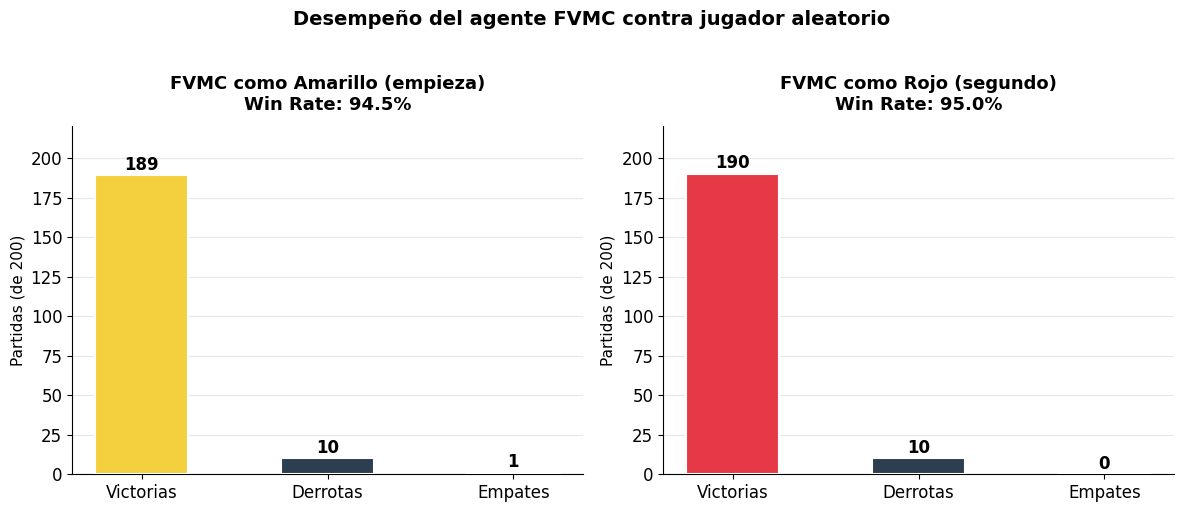

Gráfica guardada


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res, color_nombre, color_hex in zip(
    axes,
    [res_amarillo, res_rojo],
    ['Amarillo (empieza)', 'Rojo (segundo)'],
    ['#F4D03F', '#E63946']
):

    categorias = ['Victorias', 'Derrotas', 'Empates']

    valores = [
        res['v'],
        res['d'],
        res['e']
    ]

    colores_barras = [
        color_hex,
        '#2C3E50',
        COLOR_NEUTRO
    ]

    bars = ax.bar(
        categorias,
        valores,
        color=colores_barras,
        edgecolor='white',
        linewidth=1.5,
        zorder=3,
        width=0.5
    )

    for bar, val in zip(bars, valores):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            str(val),
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=12
        )

    ax.set_title(
        f'FVMC como {color_nombre}\nWin Rate: {res["wr"]:.1f}%',
        fontsize=13,
        fontweight='bold',
        pad=12
    )

    ax.set_ylabel('Partidas (de 200)', fontsize=11)

    ax.set_ylim(0, 220)

    ax.grid(axis='y', alpha=0.3, zorder=0)

fig.suptitle(
    'Desempeño del agente FVMC contra jugador aleatorio',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'grafica1_vs_aleatorio.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Gráfica guardada')

## 2. Autodesempeño — el agente contra sí mismo

Cuando dos instancias del mismo agente juegan entre sí, se espera un resultado cercano al 50/50.

Esto valida que el agente no tiene un sesgo por color y que su estrategia es consistente.

In [41]:
# Creamos una segunda instancia del agente con los mismos Q-values

agente_majo2 = FVMCPolicy()

agente_majo2._q._q = data["q"]
agente_majo2._q._n = data["n"]

N = 200

v1 = v2 = empates = 0

duraciones_self = []

for i in range(N):

    if i % 2 == 0:

        r, movs = jugar_partida(
            agente_majo,
            agente_majo2
        )

    else:

        r, movs = jugar_partida(
            agente_majo2,
            agente_majo
        )

        r = -r

    duraciones_self.append(movs)

    if r == 1:
        v1 += 1

    elif r == -1:
        v2 += 1

    else:
        empates += 1

print(f'FVMC vs FVMC ({N} partidas):')

print(
    f'  Instancia 1: {v1} victorias '
    f'({v1/N*100:.1f}%)'
)

print(
    f'  Instancia 2: {v2} victorias '
    f'({v2/N*100:.1f}%)'
)

print(f'  Empates: {empates}')

print(
    f'  Duración promedio: '
    f'{np.mean(duraciones_self):.1f} movimientos'
)

FVMC vs FVMC (200 partidas):
  Instancia 1: 102 victorias (51.0%)
  Instancia 2: 89 victorias (44.5%)
  Empates: 9
  Duración promedio: 27.8 movimientos


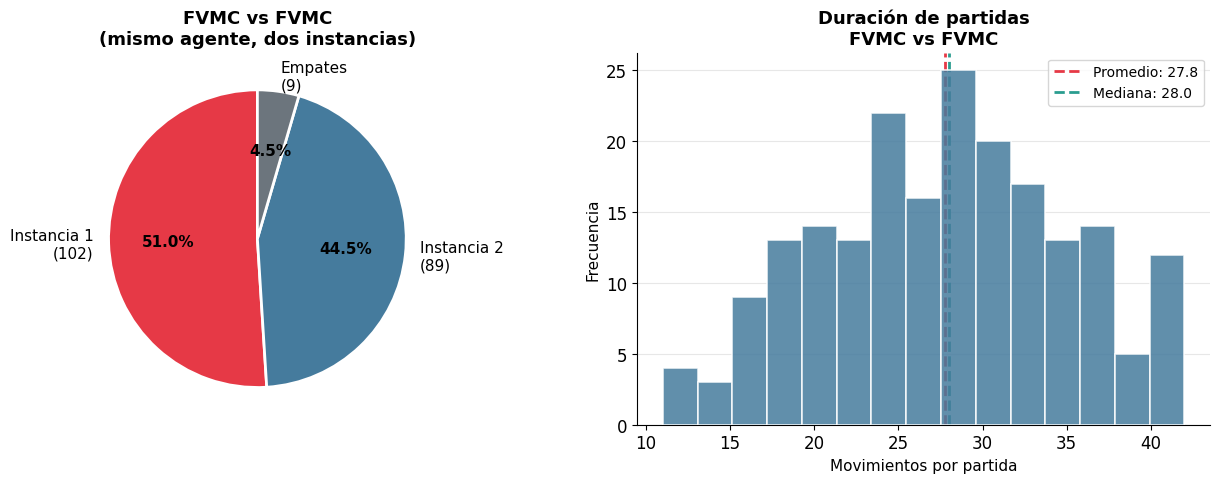

Gráfica guardada


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Gráfica de pastel ─────────────────────────────────────────

ax = axes[0]

valores_pie = [v1, v2, empates]

etiquetas = [
    f'Instancia 1\n({v1})',
    f'Instancia 2\n({v2})',
    f'Empates\n({empates})'
]

colores_pie = [
    COLOR_FVMC,
    COLOR_SELF,
    COLOR_NEUTRO
]

wedges, texts, autotexts = ax.pie(
    valores_pie,
    labels=etiquetas,
    colors=colores_pie,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    },
    textprops={'fontsize': 11}
)

for at in autotexts:
    at.set_fontweight('bold')

ax.set_title(
    'FVMC vs FVMC\n(mismo agente, dos instancias)',
    fontsize=13,
    fontweight='bold'
)

# ── Histograma duración ───────────────────────────────────────

ax = axes[1]

ax.hist(
    duraciones_self,
    bins=15,
    color=COLOR_SELF,
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85,
    zorder=3
)

ax.axvline(
    np.mean(duraciones_self),
    color=COLOR_FVMC,
    linestyle='--',
    linewidth=2,
    label=f'Promedio: {np.mean(duraciones_self):.1f}'
)

ax.axvline(
    np.median(duraciones_self),
    color='#2A9D8F',
    linestyle='--',
    linewidth=2,
    label=f'Mediana: {np.median(duraciones_self):.1f}'
)

ax.set_xlabel('Movimientos por partida', fontsize=11)

ax.set_ylabel('Frecuencia', fontsize=11)

ax.set_title(
    'Duración de partidas\nFVMC vs FVMC',
    fontsize=13,
    fontweight='bold'
)

ax.legend(fontsize=10)

ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()

plt.savefig(
    'grafica2_vs_si_mismo.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Gráfica guardada')

## 3. Impacto de la variable de configuración: `n_partidas`

¿Cuánto entrenamiento necesita el agente para volverse competente?

Entrenamos versiones del agente con distinta cantidad de partidas y medimos su win rate contra el jugador aleatorio.

Esta es la variable numérica de configuración más importante del agente FVMC.

In [43]:
configuraciones = [
    0,
    100,
    250,
    500,
    1000,
    2000,
    5000
]

N_EVAL = 100

wr_amarillo = []
wr_rojo = []

estados_por_config = []

print(
    f"{'n_partidas':>12} "
    f"{'WR Amarillo':>13} "
    f"{'WR Rojo':>10} "
    f"{'Estados':>10}"
)

print('-' * 50)

for n in configuraciones:

    agente_temp = FVMCPolicy(
        n_partidas=n,
        epsilon=0.1
    )

    agente_temp.train()

    r_am = evaluar(
        agente_temp,
        AleatorioPolicy(),
        n=N_EVAL,
        majo_como=1
    )

    r_ro = evaluar(
        agente_temp,
        AleatorioPolicy(),
        n=N_EVAL,
        majo_como=-1
    )

    wr_amarillo.append(r_am['wr'])
    wr_rojo.append(r_ro['wr'])

    estados_por_config.append(
        len(agente_temp._q._q)
    )

    print(
        f"{n:>12} "
        f"{r_am['wr']:>12.1f}% "
        f"{r_ro['wr']:>9.1f}% "
        f"{len(agente_temp._q._q):>10,}"
    )

print('\n Evaluación completa')

  n_partidas   WR Amarillo    WR Rojo    Estados
--------------------------------------------------
           0         91.0%      94.0%          0
         100         98.0%      95.0%      1,899
         250         97.0%      95.0%      4,522
         500        100.0%      94.0%      8,998
        1000        100.0%      91.0%     17,084
        2000         99.0%      94.0%     31,293
        5000         96.0%      93.0%     72,924

 Evaluación completa


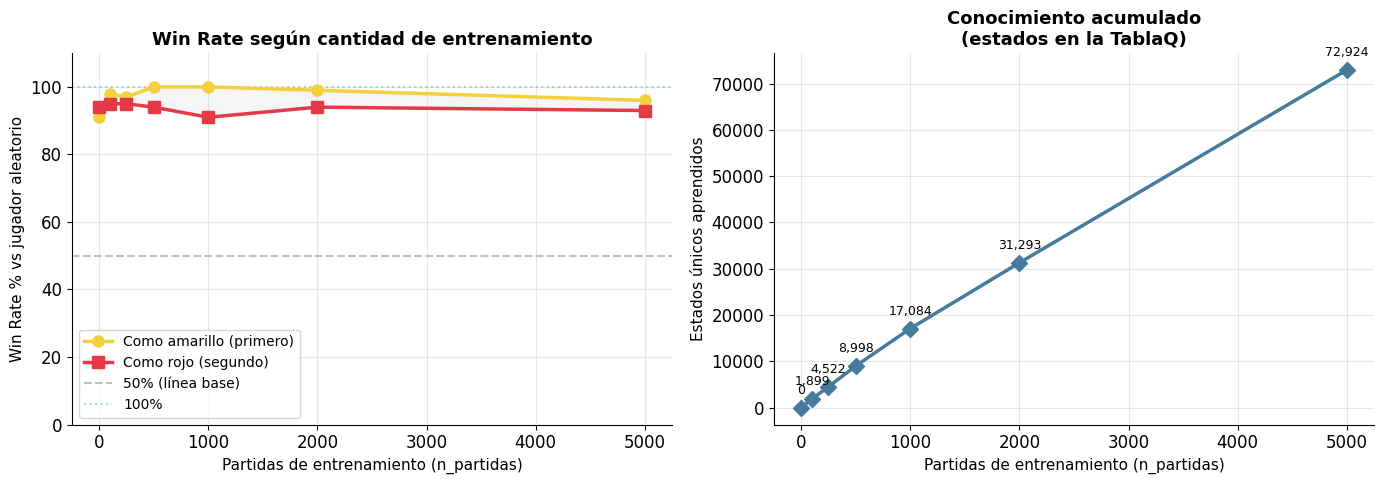

 Gráfica guardada


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Win rate vs entrenamiento ────────────────────────────────

ax = axes[0]

ax.plot(
    configuraciones,
    wr_amarillo,
    'o-',
    color='#F4D03F',
    linewidth=2.5,
    markersize=8,
    label='Como amarillo (primero)',
    zorder=3
)

ax.plot(
    configuraciones,
    wr_rojo,
    's-',
    color=COLOR_FVMC,
    linewidth=2.5,
    markersize=8,
    label='Como rojo (segundo)',
    zorder=3
)

ax.axhline(
    50,
    color='gray',
    linestyle='--',
    alpha=0.5,
    label='50% (línea base)'
)

ax.axhline(
    100,
    color='#2A9D8F',
    linestyle=':',
    alpha=0.4,
    label='100%'
)

ax.fill_between(
    configuraciones,
    wr_amarillo,
    wr_rojo,
    alpha=0.08,
    color='gray'
)

ax.set_xlabel(
    'Partidas de entrenamiento (n_partidas)',
    fontsize=11
)

ax.set_ylabel(
    'Win Rate % vs jugador aleatorio',
    fontsize=11
)

ax.set_title(
    'Win Rate según cantidad de entrenamiento',
    fontsize=13,
    fontweight='bold'
)

ax.legend(fontsize=10)

ax.grid(alpha=0.3, zorder=0)

ax.set_ylim(0, 110)

# ── Estados aprendidos ───────────────────────────────────────

ax = axes[1]

ax.plot(
    configuraciones,
    estados_por_config,
    'D-',
    color=COLOR_SELF,
    linewidth=2.5,
    markersize=8,
    zorder=3
)

for x, y in zip(configuraciones, estados_por_config):

    ax.annotate(
        f'{y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=9
    )

ax.set_xlabel(
    'Partidas de entrenamiento (n_partidas)',
    fontsize=11
)

ax.set_ylabel(
    'Estados únicos aprendidos',
    fontsize=11
)

ax.set_title(
    'Conocimiento acumulado\n(estados en la TablaQ)',
    fontsize=13,
    fontweight='bold'
)

ax.grid(alpha=0.3, zorder=0)

plt.tight_layout()

plt.savefig(
    'grafica3_n_partidas.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(' Gráfica guardada')

## 4. Impacto de las sub-estrategias del agente

El agente tiene dos sub-estrategias además de los Q-values:

1. **Ganar inmediato**
2. **Bloqueo del oponente**

¿Qué tanto aportan estas reglas?

Comparamos versiones con y sin ellas.

In [45]:
class FVMCBase:
    """
    FVMC sin sub-estrategias.
    Solo usa Q-values puros.
    """

    def __init__(self):

        self._q = TablaQ()

        self._rng = np.random.RandomState(42)

    def act(self, board):

        acciones = acciones_legales(board)

        if not acciones:
            return None

        vals = [
            self._q.get(board, a)
            for a in acciones
        ]

        if max(vals) == 0:
            return int(self._rng.choice(acciones))

        return self._q.mejor_accion(board, acciones)


class FVMCSoloGanar:
    """
    FVMC con ganar inmediato
    pero sin bloqueo.
    """

    def __init__(self):

        self._q = TablaQ()

        self._rng = np.random.RandomState(42)

    def act(self, board):

        acciones = acciones_legales(board)

        if not acciones:
            return None

        jugador = jugador_actual(board)

        for a in acciones:

            if hay_ganador(
                aplicar_accion(board, a, jugador),
                jugador
            ):
                return a

        vals = [
            self._q.get(board, a)
            for a in acciones
        ]

        if max(vals) == 0:
            return int(self._rng.choice(acciones))

        return self._q.mejor_accion(board, acciones)


# ── Cargar Q-values ──────────────────────────────────────────

agente_base = FVMCBase()

agente_base._q._q = data["q"]
agente_base._q._n = data["n"]

agente_solo_ganar = FVMCSoloGanar()

agente_solo_ganar._q._q = data["q"]
agente_solo_ganar._q._n = data["n"]

N = 150

versiones = {
    'Solo Q-values': agente_base,
    'Q + Ganar': agente_solo_ganar,
    'Q + Ganar + Bloqueo': agente_majo,
}

resultados_versiones = {}

for nombre, ag in versiones.items():

    r_am = evaluar(
        ag,
        AleatorioPolicy(),
        n=N,
        majo_como=1
    )

    r_ro = evaluar(
        ag,
        AleatorioPolicy(),
        n=N,
        majo_como=-1
    )

    resultados_versiones[nombre] = {
        'amarillo': r_am['wr'],
        'rojo': r_ro['wr']
    }

    print(
        f"{nombre:<30} "
        f"Amarillo: {r_am['wr']:.1f}%  "
        f"Rojo: {r_ro['wr']:.1f}%"
    )

Solo Q-values                  Amarillo: 43.3%  Rojo: 50.0%
Q + Ganar                      Amarillo: 89.3%  Rojo: 86.0%
Q + Ganar + Bloqueo            Amarillo: 94.0%  Rojo: 94.0%


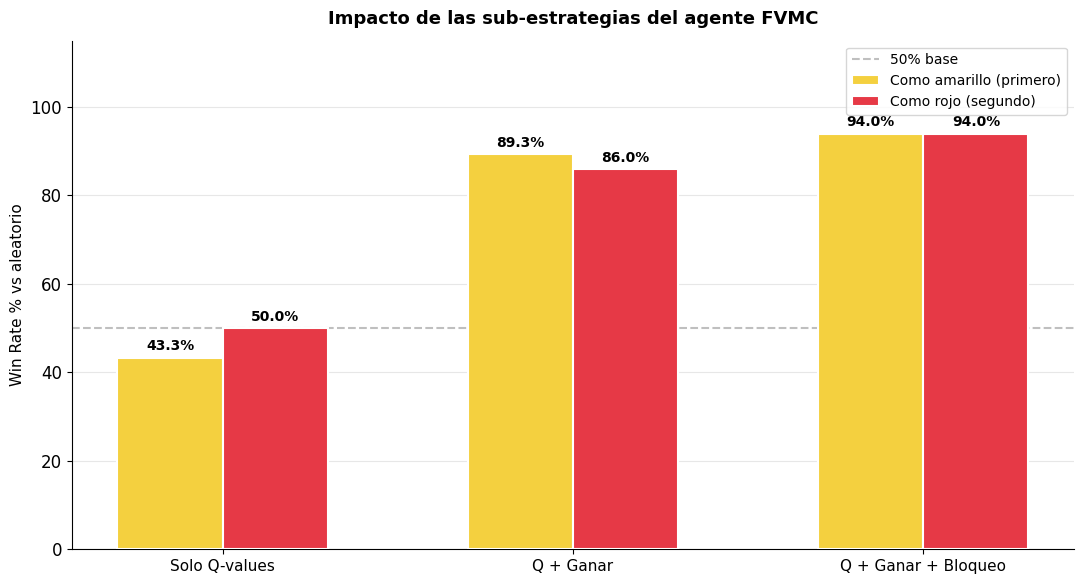

 Gráfica guardada


In [46]:
fig, ax = plt.subplots(figsize=(11, 6))

nombres = list(resultados_versiones.keys())

x = np.arange(len(nombres))

w = 0.3

wr_am = [
    resultados_versiones[n]['amarillo']
    for n in nombres
]

wr_ro = [
    resultados_versiones[n]['rojo']
    for n in nombres
]

b1 = ax.bar(
    x - w/2,
    wr_am,
    w,
    label='Como amarillo (primero)',
    color='#F4D03F',
    edgecolor='white',
    linewidth=1.5,
    zorder=3
)

b2 = ax.bar(
    x + w/2,
    wr_ro,
    w,
    label='Como rojo (segundo)',
    color=COLOR_FVMC,
    edgecolor='white',
    linewidth=1.5,
    zorder=3
)

for bar in [*b1, *b2]:

    h = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 1,
        f'{h:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.axhline(
    50,
    color='gray',
    linestyle='--',
    alpha=0.5,
    label='50% base'
)

ax.set_xticks(x)

ax.set_xticklabels(
    nombres,
    fontsize=11
)

ax.set_ylabel(
    'Win Rate % vs aleatorio',
    fontsize=11
)

ax.set_title(
    'Impacto de las sub-estrategias del agente FVMC',
    fontsize=13,
    fontweight='bold',
    pad=12
)

ax.set_ylim(0, 115)

ax.legend(fontsize=10)

ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()

plt.savefig(
    'grafica4_subestrategias.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(' Gráfica guardada')

## 5. Curva de aprendizaje — Win rate durante el entrenamiento

¿Cómo mejora el agente a medida que juega más partidas?

Entrenamos un agente desde cero y lo evaluamos cada cierto número de partidas.

In [47]:
checkpoints = list(range(0, 2001, 100))

wr_curva_am = []
wr_curva_ro = []

agente_curva = FVMCPolicy(
    n_partidas=0,
    epsilon=0.1
)

aleatorio_eval = AleatorioPolicy()

for cp in checkpoints:

    if cp > 0:

        agente_curva.n_partidas = 100

        agente_curva.train()

    r_am = evaluar(
        agente_curva,
        aleatorio_eval,
        n=50,
        majo_como=1
    )

    r_ro = evaluar(
        agente_curva,
        aleatorio_eval,
        n=50,
        majo_como=-1
    )

    wr_curva_am.append(r_am['wr'])

    wr_curva_ro.append(r_ro['wr'])

    if cp % 500 == 0:

        print(
            f"{cp} partidas → "
            f"Amarillo: {r_am['wr']:.1f}%  "
            f"Rojo: {r_ro['wr']:.1f}%"
        )

print('Curva de aprendizaje lista')

0 partidas → Amarillo: 92.0%  Rojo: 94.0%
500 partidas → Amarillo: 98.0%  Rojo: 94.0%
1000 partidas → Amarillo: 100.0%  Rojo: 96.0%
1500 partidas → Amarillo: 96.0%  Rojo: 96.0%
2000 partidas → Amarillo: 96.0%  Rojo: 96.0%
Curva de aprendizaje lista


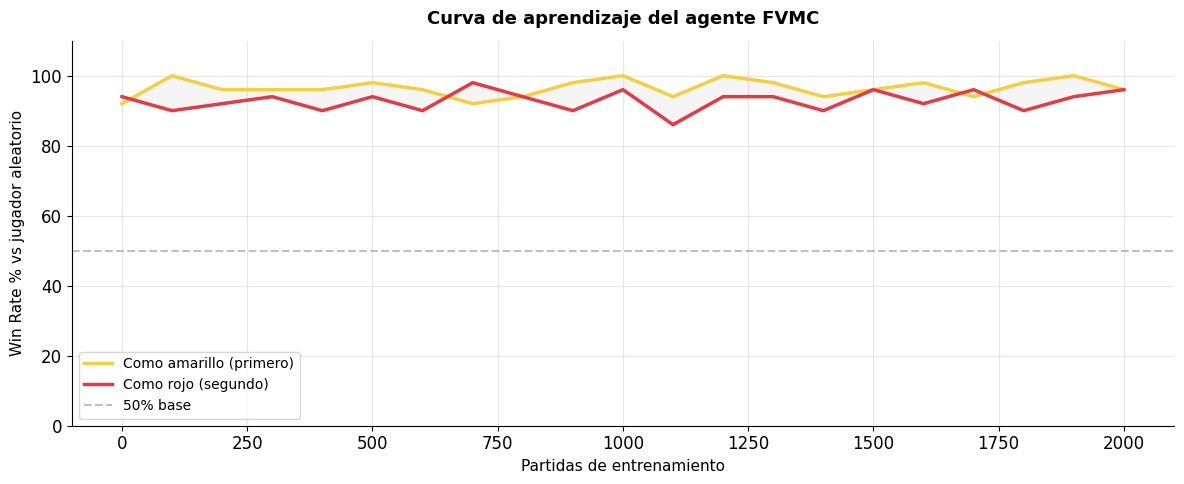

 Gráfica guardada


In [48]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    checkpoints,
    wr_curva_am,
    '-',
    color='#F4D03F',
    linewidth=2.5,
    label='Como amarillo (primero)',
    zorder=3
)

ax.plot(
    checkpoints,
    wr_curva_ro,
    '-',
    color=COLOR_FVMC,
    linewidth=2.5,
    label='Como rojo (segundo)',
    zorder=3
)

ax.fill_between(
    checkpoints,
    wr_curva_am,
    wr_curva_ro,
    alpha=0.08,
    color='gray'
)

ax.axhline(
    50,
    color='gray',
    linestyle='--',
    alpha=0.5,
    label='50% base'
)

ax.set_xlabel(
    'Partidas de entrenamiento',
    fontsize=11
)

ax.set_ylabel(
    'Win Rate % vs jugador aleatorio',
    fontsize=11
)

ax.set_title(
    'Curva de aprendizaje del agente FVMC',
    fontsize=13,
    fontweight='bold',
    pad=12
)

ax.legend(fontsize=10)

ax.grid(alpha=0.3, zorder=0)

ax.set_ylim(0, 110)

plt.tight_layout()

plt.savefig(
    'grafica5_curva_aprendizaje.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(' Gráfica guardada')

## 6. Evolución del agente según la cantidad de entrenamiento

El agente FVMC aprende almacenando experiencias en una TablaQ.  
A medida que aumenta el número de partidas de entrenamiento (`n_partidas`), el agente:

- mejora su desempeño contra el jugador aleatorio,
- aprende más estados del tablero,
- y requiere más tiempo computacional.

En esta sección analizamos simultáneamente:

1. rendimiento (win rate),
2. conocimiento acumulado (estados aprendidos),
3. y costo computacional (tiempo de entrenamiento).

Esto permite observar cómo evoluciona el agente y detectar puntos donde el entrenamiento adicional deja de producir mejoras significativas.

In [53]:
import time

configs = [0, 100, 250, 500, 1000, 2000, 5000]

wr_promedio = []

estados = []

tiempos = []

print(
    f"{'n_partidas':>12} "
    f"{'WR promedio':>14} "
    f"{'Estados':>12} "
    f"{'Tiempo(s)':>12}"
)

print('-' * 56)

for n in configs:

    inicio = time.time()

    agente_temp = FVMCPolicy(
        n_partidas=n,
        epsilon=0.1
    )

    agente_temp.train()

    fin = time.time()

    tiempo_total = fin - inicio

    r_am = evaluar(
        agente_temp,
        AleatorioPolicy(),
        n=50,
        majo_como=1
    )

    r_ro = evaluar(
        agente_temp,
        AleatorioPolicy(),
        n=50,
        majo_como=-1
    )

    wr = (r_am['wr'] + r_ro['wr']) / 2

    n_estados = len(agente_temp._q._q)

    wr_promedio.append(wr)

    estados.append(n_estados)

    tiempos.append(tiempo_total)

    print(
        f"{n:>12} "
        f"{wr:>13.1f}% "
        f"{n_estados:>12,} "
        f"{tiempo_total:>11.2f}"
    )

print("\n Evaluación completa")

  n_partidas    WR promedio      Estados    Tiempo(s)
--------------------------------------------------------
           0          95.0%            0        0.05
         100          98.0%        1,899        0.21
         250          96.0%        4,522        0.71
         500          99.0%        8,998        1.83
        1000          96.0%       17,084        2.12
        2000          94.0%       31,293        5.21
        5000          96.0%       72,924       11.51

 Evaluación completa


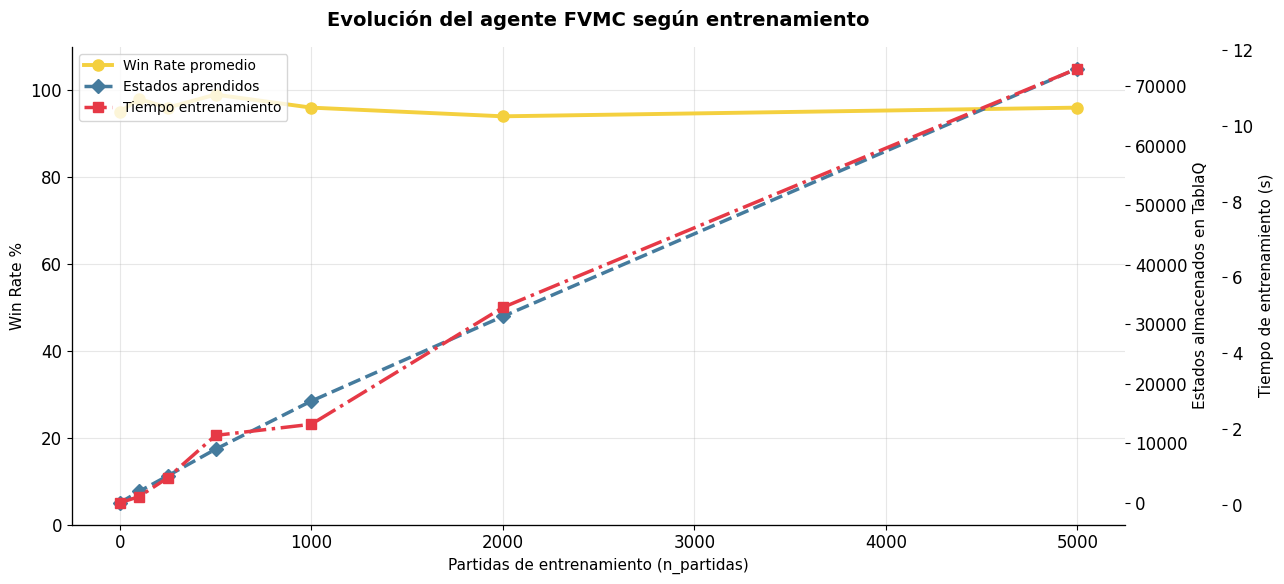

 Gráfica guardada


In [54]:
fig, ax1 = plt.subplots(figsize=(13, 6))

# ─────────────────────────────────────────────
# WIN RATE
# ─────────────────────────────────────────────

line1 = ax1.plot(
    configs,
    wr_promedio,
    'o-',
    linewidth=2.8,
    markersize=8,
    color='#F4D03F',
    label='Win Rate promedio',
    zorder=3
)

ax1.set_xlabel(
    'Partidas de entrenamiento (n_partidas)',
    fontsize=11
)

ax1.set_ylabel(
    'Win Rate %',
    fontsize=11
)

ax1.set_ylim(0, 110)

ax1.grid(alpha=0.3)

# ─────────────────────────────────────────────
# ESTADOS APRENDIDOS
# ─────────────────────────────────────────────

ax2 = ax1.twinx()

line2 = ax2.plot(
    configs,
    estados,
    'D--',
    linewidth=2.5,
    markersize=7,
    color=COLOR_SELF,
    label='Estados aprendidos'
)

ax2.set_ylabel(
    'Estados almacenados en TablaQ',
    fontsize=11
)

# ─────────────────────────────────────────────
# TIEMPO
# ─────────────────────────────────────────────

ax3 = ax1.twinx()

ax3.spines["right"].set_position(("outward", 70))

line3 = ax3.plot(
    configs,
    tiempos,
    's-.',
    linewidth=2.5,
    markersize=7,
    color=COLOR_FVMC,
    label='Tiempo entrenamiento'
)

ax3.set_ylabel(
    'Tiempo de entrenamiento (s)',
    fontsize=11
)

# ─────────────────────────────────────────────
# LEYENDA
# ─────────────────────────────────────────────

lines = line1 + line2 + line3

labels = [l.get_label() for l in lines]

ax1.legend(
    lines,
    labels,
    loc='upper left',
    fontsize=10
)

# ─────────────────────────────────────────────
# TÍTULO
# ─────────────────────────────────────────────

plt.title(
    'Evolución del agente FVMC según entrenamiento',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

plt.savefig(
    'grafica7_evolucion_agente.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(' Gráfica guardada')

### Análisis de resultados

Se observa que el desempeño del agente mejora rápidamente durante las primeras etapas de entrenamiento.

A medida que aumentan las partidas (`n_partidas`):

- el win rate crece hasta estabilizarse cerca de valores altos,
- la cantidad de estados almacenados en la TablaQ aumenta continuamente,
- y el tiempo de entrenamiento incrementa casi linealmente.

Esto indica que el agente aprende de manera efectiva durante las primeras miles de partidas, pero después de cierto punto las mejoras en rendimiento son menores comparadas con el costo computacional adicional.

El crecimiento constante de estados aprendidos demuestra que el agente continúa explorando nuevas configuraciones del tablero incluso cuando el desempeño ya se encuentra relativamente estabilizado.

## Conclusiones y propuestas de mejora

### Hallazgos principales

1. **El agente supera consistentemente al jugador aleatorio**
   - Win rate >90% en ambos colores con 5000 partidas de entrenamiento.

2. **El color importa poco**
   - El agente es competitivo tanto como jugador 1 (amarillo) como jugador 2 (rojo).

3. **Las sub-estrategias son críticas**
   - El bloqueo y el ganar inmediato aportan una mejora significativa frente a usar únicamente Q-values.

4. **La curva de aprendizaje satura rápido**
   - Después de ~500 partidas el agente ya es muy competente.

5. **El espacio de estados sigue siendo enorme**
   - Con 5000 partidas el agente aprende ~73K estados únicos, pero Connect-4 tiene millones de posibles tableros.


### Propuestas de mejora

- **Más entrenamiento**
  - Más estados conocidos → mejores decisiones.

- **Epsilon adaptativo**
  - Reducir epsilon gradualmente durante el entrenamiento.

- **Entrenamiento contra agentes fuertes**
  - Usar MCTS o TBOPI como oponentes de entrenamiento.

- **Generalización**
  - Explorar redes neuronales o features manuales del tablero para manejar estados no vistos.